# The Monte Carlo estimator

Sample encounters, run them, count what happened. `estimate_ipr` is the plain estimator and the one
to reach for unless the number you want is too rare to observe.

Nothing is reweighted and nothing is thrown away, which is the property everything below follows
from: the batch you end up with is a sample of the real encounter population, so it answers
questions you had not thought of when you started it.

In [1]:
%matplotlib inline
import dataclasses
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import GnssNavigation, M600, MVP, PastCPA, StateBased
from opencdarr.config import load_config
from opencdarr.estimator import combine_ipr, estimate_ipr, wilson_interval
from opencdarr.rng import children, root_seed_sequence

BLUE, RED, GREY = "#1f77b4", "#d62728", "0.45"
RPZ = 50.0

base = load_config("../../configs/pairwise.yaml")
cfg = dataclasses.replace(
    base,
    seed=0,
    n_encounters=500,
    scenario=dataclasses.replace(
        base.scenario, speed=10.0, tlos=180.0, pos_ci95=10.0, vel_ci95=1.0
    ),
)
print(f"n_encounters {cfg.n_encounters}   seed {cfg.seed}   rpz {cfg.conflict.rpz:.0f} m"
      f"   lookahead {cfg.conflict.t_lookahead:.0f} s   tlos {cfg.scenario.tlos:.0f} s")

# The handbook page for this notebook publishes its figures. They are written from here rather than
# redrawn by a separate script, so the page and the notebook cannot disagree about a number.
SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)

n_encounters 500   seed 0   rpz 50 m   lookahead 120 s   tlos 180 s


## One call

`estimate_ipr` takes the config, the aircraft performance, and the CDR stack. The geometry slots
(`dpsi`, `dcpa`, `side`, `gs_intr`) pin one parameter of the sampled encounter; left alone they are
drawn. Here we pin a 2° crossing with a head-on miss distance — the hardest case at that angle.

In [2]:
result = estimate_ipr(
    cfg, M600, StateBased(), MVP(1.05), PastCPA(), GnssNavigation(),
    dpsi=2.0, dcpa=0.0,
)

print(f"p_los           {result.p_los:.3f}")
print(f"ci95            ({result.ci95[0]:.3f}, {result.ci95[1]:.3f})   95% Wilson")
print(f"median_min_sep  {result.median_min_sep:.1f} m")
print(f"ipr             {result.ipr:.3f}")
print(f"counts          {result.n_los} LoS in {result.n_encounters} encounters")
print(f"detection_rate  {result.detection_rate:.3f}")

p_los           0.050
ci95            (0.034, 0.073)   95% Wilson
median_min_sep  53.3 m
ipr             0.950
counts          25 LoS in 500 encounters
detection_rate  0.972


## The unit is the encounter

One encounter is **one simulation run from one seed**: one sampled geometry, flown from spawn to
termination, giving one outcome. The denominator of `p_los` is `n_encounters` — a number *you
chose*, not one the run discovered.

That distinction is not pedantry. The estimator used to divide by "encounters where the detector
fired", which sounds reasonable and is not: a conflict detector reports nothing once the predicted
miss exceeds the protected zone, so a resolver that builds separation early **erases the conflict
from its own denominator**.

`detection_rate` is what that quantity became — a diagnostic, never a divisor. Watch it move with
the resolver while the denominator does not.

In [3]:
probe = dataclasses.replace(cfg, n_encounters=300)

print(f"{'pos/vel accuracy':>18} {'resolver':>9} {'n_encounters':>13} {'n_conflict':>11}"
      f" {'p_los':>7}")
for pos, vel in ((0.0, 0.0), (10.0, 1.0), (60.0, 6.0)):
    scen = dataclasses.replace(probe.scenario, pos_ci95=pos, vel_ci95=vel)
    for resolver, name in ((None, "none"), (MVP(1.05), "MVP")):
        r = estimate_ipr(
            dataclasses.replace(probe, scenario=scen), M600, StateBased(), resolver,
            PastCPA() if resolver else None,
            GnssNavigation() if pos or vel else None,
        )
        print(f"{f'{pos:.0f} m / {vel:.0f} m/s':>18} {name:>9} {r.n_encounters:>13}"
              f" {r.n_conflict:>11} {r.p_los:>7.3f}")

  pos/vel accuracy  resolver  n_encounters  n_conflict   p_los


       0 m / 0 m/s      none           300         299   0.993


       0 m / 0 m/s       MVP           300         299   0.000


      10 m / 1 m/s      none           300         299   0.993


      10 m / 1 m/s       MVP           300         164   0.000


      60 m / 6 m/s      none           300         299   0.993


      60 m / 6 m/s       MVP           300         276   0.080


With no resolver the count sits at 299 of 300 whatever the noise — flat, because it is a property of
the sampled geometry. Switch the resolver on and it drops to **164** at a 10 m fix, then back up to
**276** at 60 m. The shortfall appears only when resolution is active, and it is not even monotone
in the noise, so there is no correction to apply: a resolver would be graded only on the conflicts
it failed to pre-empt, and the better it worked the smaller its own denominator.

**A denominator must be fixed by the experiment design, never discovered from the run.** Anything
whose count depends on behaviour is a numerator or a distribution — never a divisor.

Because the scenario layer builds every sampled encounter to be a genuine conflict, IPR and P(LoS)
are one quantity under two names: `ipr == 1 - p_los`.

## The interval

A rate from a fixed number of trials is a binomial proportion, so it gets a **Wilson score
interval** rather than the textbook $\hat p \pm z\sqrt{\hat p(1-\hat p)/n}$. The normal
approximation misbehaves exactly where safety numbers live: near zero it runs below 0, and at zero
observed events it collapses to $(0, 0)$ — false certainty from a batch that saw nothing.

      n  width at 5%   upper bound, k = 0
    100       0.0902               0.0370
    500       0.0387               0.0076
   2000       0.0192               0.0019
  10000       0.0085               0.0004


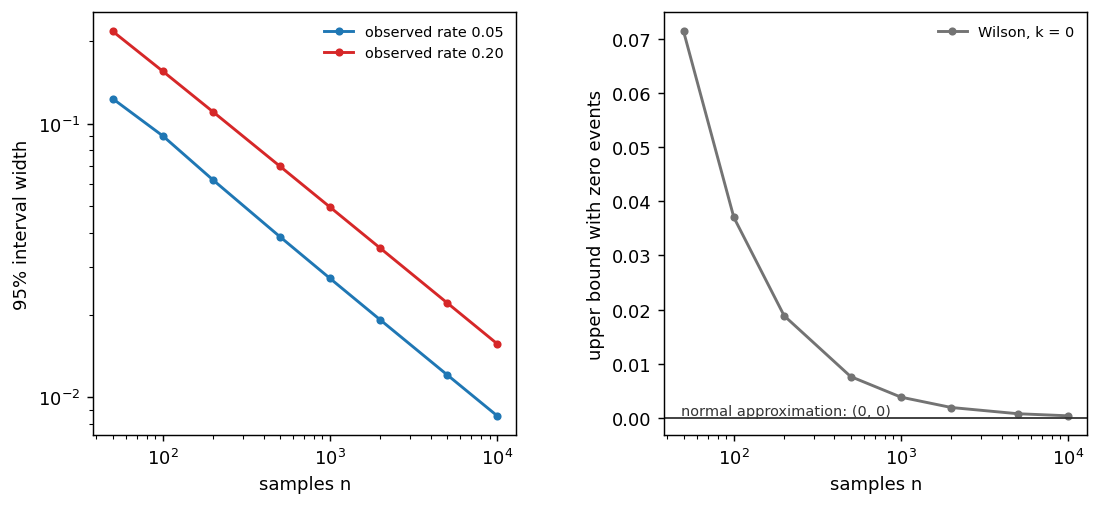

In [4]:
ns = np.array([50, 100, 200, 500, 1000, 2000, 5000, 10000])

fig, (ax_w, ax_z) = plt.subplots(1, 2, figsize=(9.0, 4.0))

for k_frac, colour in ((0.05, BLUE), (0.20, RED)):
    lo, hi = np.array([wilson_interval(round(k_frac * n), n) for n in ns]).T
    ax_w.plot(ns, hi - lo, marker="o", ms=3.5, lw=1.6, color=colour,
              label=f"observed rate {k_frac:.2f}")
ax_w.set_xscale("log")
ax_w.set_yscale("log")
ax_w.set_xlabel("samples n")
ax_w.set_ylabel("95% interval width")
ax_w.set_box_aspect(1)
ax_w.legend(frameon=False, fontsize=8)

zero = np.array([wilson_interval(0, n)[1] for n in ns])
ax_z.plot(ns, zero, marker="o", ms=3.5, lw=1.6, color=GREY, label="Wilson, k = 0")
ax_z.axhline(0.0, color="0.2", lw=1.0)
ax_z.annotate("normal approximation: (0, 0)", (0.04, 0.0),
              xycoords=("axes fraction", "data"), va="bottom", fontsize=8, color="0.2")
ax_z.set_xscale("log")
ax_z.set_xlabel("samples n")
ax_z.set_ylabel("upper bound with zero events")
ax_z.set_box_aspect(1)
ax_z.legend(frameon=False, fontsize=8)

# a log axis spanning less than a decade starts labelling minor ticks, which collide
for ax in (ax_w, ax_z):
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

fig.tight_layout()
publish(fig, "mc-interval")

print(f"{'n':>7} {'width at 5%':>12} {'upper bound, k = 0':>20}")
for n in (100, 500, 2000, 10000):
    lo, hi = wilson_interval(round(0.05 * n), n)
    print(f"{n:>7} {hi - lo:>12.4f} {wilson_interval(0, n)[1]:>20.4f}")

The width shrinks as $1/\sqrt{n}$ — a straight line of slope $-\tfrac12$ on the log-log axes.

The right panel is the one worth remembering. **Zero losses in 500 encounters returns an upper bound
of 0.0076**, not zero: the honest reading is *the rate is below about 0.8%*. Any cell of a sweep
reporting `0.000` should be read that way.

## Every encounter is kept

The estimator stores the achieved minimum separation of each encounter, so the reported metrics are
reductions of a record rather than the only things measured. `P(LoS)` is one point on that
distribution; every other point is a read, not another simulation.

encounters       500
P(min_sep < 50)  0.050   <- this is p_los, by definition
P(min_sep < 25)  0.000
P(min_sep < 10)  0.000
quartiles        [51.8 53.3 55. ] m


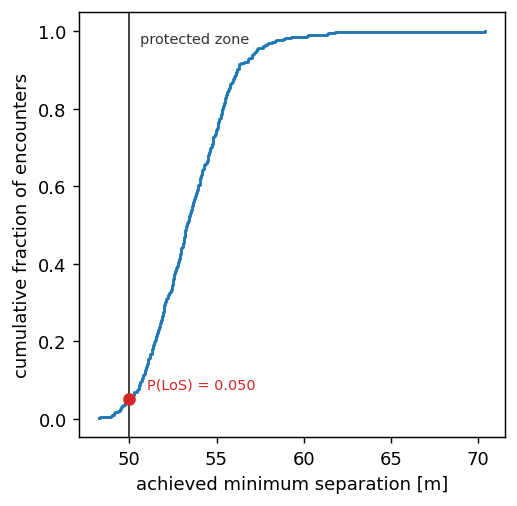

In [5]:
seps = np.array(result.min_seps)

print(f"encounters       {len(seps)}")
print(f"P(min_sep < 50)  {(seps < RPZ).mean():.3f}   <- this is p_los, by definition")
print(f"P(min_sep < 25)  {(seps < 25).mean():.3f}")
print(f"P(min_sep < 10)  {(seps < 10).mean():.3f}")
print(f"quartiles        {np.percentile(seps, [25, 50, 75]).round(1)} m")

fig, ax = plt.subplots(figsize=(5.2, 4.0))
order = np.sort(seps)
ax.step(order, np.arange(1, len(order) + 1) / len(order), where="post", lw=1.6, color=BLUE)
ax.axvline(RPZ, color="0.2", lw=1.0)
ax.plot([RPZ], [(seps < RPZ).mean()], marker="o", ms=6, color=RED, zorder=3)
ax.annotate(f"P(LoS) = {(seps < RPZ).mean():.3f}", (RPZ, (seps < RPZ).mean()),
            textcoords="offset points", xytext=(10, 6), fontsize=8, color=RED)
ax.annotate("protected zone", (RPZ, 0.97), textcoords="offset points", xytext=(6, 0),
            fontsize=8, color="0.2")
ax.set_xlabel("achieved minimum separation [m]")
ax.set_ylabel("cumulative fraction of encounters")
ax.set_box_aspect(1)
fig.tight_layout()
publish(fig, "mc-cpa-distribution")

`p_los` is the height of this curve where it crosses the protected zone. Every other height is
available for free, which is what a splitting estimator cannot offer — its surviving cloud samples
the rare set rather than the population, so there is no unbiased population median in it to report.

`los` and `min_sep` are not two measurements: the fleet loop accumulates both from the same per-step
segment minimum, so `los` is exactly `min_sep < rpz`. That identity is what makes the first line
above true *by definition* rather than by coincidence.

## Reproducibility and chunking

`config + seed + code-hash → result`, with no hidden state. Encounters are independent, so a batch
splits across processes — but **only by slicing the one seed tree the serial run walks**.

In [6]:
small = dataclasses.replace(cfg, n_encounters=120)
stack = dict(perf=M600, detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(),
             navigation=GnssNavigation())


def run(config, **kw):
    return estimate_ipr(config, stack["perf"], stack["detector"], stack["resolver"],
                        stack["recovery"], stack["navigation"], dpsi=2.0, dcpa=0.0, **kw)


whole = run(small)
root = root_seed_sequence(small.seed)

for jobs in (3, 7):  # 7 divides 120 unevenly, so the bounds are ragged
    bounds = [(120 * i // jobs, 120 * (i + 1) // jobs) for i in range(jobs)]
    pooled = combine_ipr([run(small, seqs=children(root, lo, hi)) for lo, hi in bounds])
    print(f"{jobs} chunks -> identical to the serial run: {pooled == whole}")

# the wrong way: a fresh tree per chunk
offset = combine_ipr([
    run(dataclasses.replace(small, seed=small.seed + i, n_encounters=40)) for i in range(3)
])
print(f"\nseed + i per chunk: {offset.n_los} LoS vs {whole.n_los} serial"
      f"  -> same size, different encounters")

3 chunks -> identical to the serial run: True


7 chunks -> identical to the serial run: True



seed + i per chunk: 3 LoS vs 7 serial  -> same size, different encounters


`children(root, lo, hi)` addresses a contiguous slice of the *same* fan-out the serial run walks, so
pooling the slices with `combine_ipr` reproduces the serial answer exactly — counts and the
per-encounter record, element by element.

Rooting each chunk at `seed + i` gives a different tree altogether. Those trees can correlate, and
their union is not the serial run's tree at all, so the result is a different (and less defensible)
estimate rather than the same one computed in parallel.

`combine_ipr` sums counts and recomputes the rates from the pooled totals. Averaging per-chunk
ratios would weight a chunk of few encounters as heavily as one of many.

## Where it runs out

Seeing an event $k$ times takes roughly $k/p$ encounters. At $10^{-6}$ that is millions of runs for
a handful of observations, and at the $10^{-9}$ safety targets that matter it is not a question of
patience.

In [7]:
print(f"{'true rate p':>12} {'runs for ~10 events':>21} {'runs for 10% precision':>24}")
for p in (1e-2, 1e-3, 1e-4, 1e-6, 1e-9):
    # 10% relative precision on a binomial: n ~ (1.96 / 0.1)^2 * (1 - p) / p
    n_prec = (1.96 / 0.10) ** 2 * (1 - p) / p
    print(f"{p:>12.0e} {10 / p:>21,.0f} {n_prec:>24,.0f}")

 true rate p   runs for ~10 events   runs for 10% precision
       1e-02                 1,000                   38,032
       1e-03                10,000                  383,776
       1e-04               100,000                3,841,216
       1e-06            10,000,000              384,159,616
       1e-09        10,000,000,000          384,159,999,616


The practical boundary is softer than the arithmetic: it is wherever the interval stops being narrow
enough to answer the question. At 500 encounters a 5% rate is resolved comfortably and two resolvers
that both sit at zero cannot be told apart. Past that point a splitting estimator estimates the same
quantity from far fewer runs.

## In the code

`estimate_ipr` runs the batch and returns an `IPRResult` carrying `min_seps`, `n_los` and
`n_conflict`, with `p_los`, `ipr`, `ci95`, `median_min_sep` and `detection_rate` derived from them so
they cannot drift out of step with the counts. Each encounter is one `run_fleet` — the same
environment the rare-event estimator drives, which is what makes the two comparable.

- `opencdarr/estimator.py` — `estimate_ipr`, `IPRResult`, `combine_ipr`, `wilson_interval`
- `opencdarr/rng.py` — `root_seed_sequence`, `spawn`, `children`
- `opencdarr/fleet.py` — `run_fleet`, and the `advance` / `is_terminal` seam both estimators drive